# 🏥 Diabetes Risk Prediction — Early Detection System  
## Notebook 3: Model Training & Evaluation

**Author:** Cephas Adams Kumah  
**Dataset:** CDC Diabetes Health Indicators — BRFSS 2015  
**Input:** `X_train.csv`, `X_test.csv`, `y_train.csv`, `y_test.csv`  
**Models:** Logistic Regression baseline · XGBoost final model  
**Objective:** Train and compare binary classification models to predict diabetes risk, evaluate performance using clinically appropriate metrics, and export the final model with prediction outputs for the Streamlit web application.

---

| Step | Description |
|---|---|
| 1. Load Data | Import prepared train and test datasets from Notebook 2 |
| 2. Baseline Model | Train Logistic Regression as a simple interpretable baseline |
| 3. XGBoost Model | Train the final XGBoost classifier using imbalance-aware weighting |
| 4. Model Comparison | Compare models using ROC-AUC, Recall, Precision, F1-score, and Confusion Matrix |
| 5. Feature Importance | Analyse XGBoost built-in feature importance scores |
| 6. SHAP Analysis | Use SHAP values to explain model predictions and support clinical interpretation |
| 7. Export Model Assets | Save the trained model, scaler, feature list, predictions, and explanation outputs for the Streamlit app |

## 1. Load Data

The prepared training and test datasets exported from Notebook 2 are loaded for model development.

Two versions of the feature sets are used:

- **Scaled feature sets** are used for the Logistic Regression baseline model because Logistic Regression is sensitive to feature magnitude.
- **Unscaled feature sets** are used for XGBoost because tree-based models are scale-invariant and do not require standardisation.

The target labels, `y_train` and `y_test`, are loaded separately and reused for both models.

In [5]:
import pandas as pd
import numpy as  np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    ConfusionMatrixDisplay
)

import xgboost as xgb
import shap
import pickle

# Load unscaled for XGBoost
X_train =  pd.read_csv('../data/X_train.csv')
X_test  =  pd.read_csv('../data/X_test.csv')
y_train =  pd.read_csv('../data/y_train.csv').squeeze()
y_test  =  pd.read_csv('../data/y_test.csv').squeeze()

#Load scaled for Logistic Regression
X_train_scaled = pd.read_csv('../data/X_train_scaled.csv')
X_test_scaled = pd.read_csv('../data/X_test_scaled.csv')

print("=" * 40)
print(f"  X_train: {X_train.shape}")
print(f"  X_test:  {X_test.shape}")
print(f"  y_train: {y_train.shape}")
print(f"  y_test:  {y_test.shape}")
print("=" * 40)

  X_train: (183579, 21)
  X_test:  (45895, 21)
  y_train: (183579,)
  y_test:  (45895,)


## 2. Baseline Model — Logistic Regression

Logistic Regression is trained as a simple and interpretable baseline model. Its performance provides a minimum benchmark that the XGBoost model must exceed to justify the added complexity.

Because the dataset is imbalanced, with approximately **85% No Diabetes** and **15% Diabetes**, `class_weight='balanced'` is used. This adjusts the model so that the minority class receives more weight during training, helping the model pay more attention to diabetic cases.

**Why Recall matters most here:**  
In a clinical screening context, missing a respondent who may be diabetic represents a false negative. This is more concerning than incorrectly flagging a non-diabetic respondent as high risk, because the flagged person can still be referred for further testing.

For this reason, we prioritise **Recall for the diabetes class** alongside **ROC-AUC** when evaluating model performance.

In [8]:
# Train Logistic Regression
lr = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)
lr.fit(X_train_scaled, y_train)

#Evaluate 
lr_preds = lr.predict(X_test_scaled)
lr_probs = lr.predict_proba(X_test_scaled)[:, 1]
lr_auc = roc_auc_score(y_test, lr_probs)

print("="  * 45)
print(" LOGISTIC REGRESSION RESULTS")
print("="  * 45)
print(f" ROC_AUC Score: {lr_auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, lr_preds,
                           target_names=['No Diabetes', 'Diabetes']))

 LOGISTIC REGRESSION RESULTS
 ROC_AUC Score: 0.8106

Classification Report:
              precision    recall  f1-score   support

 No Diabetes       0.94      0.71      0.81     38876
    Diabetes       0.32      0.76      0.45      7019

    accuracy                           0.72     45895
   macro avg       0.63      0.73      0.63     45895
weighted avg       0.85      0.72      0.75     45895



## 3. XGBoost — Final Model

XGBoost, short for **Extreme Gradient Boosting**, is trained as the primary model for this project. It builds decision trees sequentially, where each new tree attempts to correct the errors made by the previous trees.

Compared with Logistic Regression, XGBoost can capture more complex non-linear relationships and feature interactions. This makes it suitable for a healthcare risk prediction problem where diabetes risk may depend on combinations of clinical, lifestyle, and socioeconomic factors.

Because the dataset is imbalanced, `scale_pos_weight` is used instead of `class_weight`. This is the XGBoost-native approach for handling class imbalance in binary classification.

`scale_pos_weight` is calculated as:

```python
scale_pos_weight = number of negative cases / number of positive cases

In [12]:
#Calculate scale_pos_weight for class imbalance
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale = neg/pos

print(f" scale_pos_weight: {scale:.2f}")
print(f" (Negative: {neg:,} / Positive: {pos:,})")

#Train XGBoost
xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    scale_pos_weight=scale,
    random_state=42,
    eval_metric='logloss',
    n_jobs=-1
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

# Evaluate
xgb_preds = xgb_model.predict(X_test)
xgb_probs = xgb_model.predict_proba(X_test)[:,1]
xgb_auc = roc_auc_score(y_test, xgb_probs)

print("=" * 45)
print(" XGBOOST RESULTS")
print("=" * 45)
print(f" ROC-AUC Score: {xgb_auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, xgb_preds,
       target_names=['No Diabetes', 'Diabetes']))


 scale_pos_weight: 5.54
 (Negative: 155,501 / Positive: 28,078)
 XGBOOST RESULTS
 ROC-AUC Score: 0.8179

Classification Report:
              precision    recall  f1-score   support

 No Diabetes       0.95      0.70      0.80     38876
    Diabetes       0.32      0.78      0.45      7019

    accuracy                           0.71     45895
   macro avg       0.63      0.74      0.63     45895
weighted avg       0.85      0.71      0.75     45895



## 4. Model Comparison

Both models are evaluated using four key classification metrics. In a clinical screening context, **Recall for the Diabetes class** is especially important because a missed diabetic case, known as a false negative, may delay early intervention.

| Metric | Logistic Regression | XGBoost | Winner |
|---|---:|---:|---|
| ROC-AUC | 0.8106 | 0.8179 | ✅ XGBoost |
| Recall (Diabetes) | 0.76 | 0.78 | ✅ XGBoost |
| Precision (Diabetes) | 0.32 | 0.32 | Draw |
| F1-score (Diabetes) | 0.45 | 0.45 | Draw |

**XGBoost is selected as the final model** because it achieves the best overall discrimination performance and slightly improves diabetes recall compared with Logistic Regression.

> A diabetes recall of **0.78** means the model correctly identifies **78% of respondents with diabetes** in the test set. This is clinically meaningful for an early detection screening tool, where identifying high-risk individuals is more important than maximising overall accuracy.

### ROC Curve Comparison

The ROC curve compares each model’s ability to distinguish between respondents with and without diabetes across different probability thresholds.

A model with a higher ROC-AUC score has better overall discrimination. The diagonal dashed line represents random guessing, where AUC = 0.5.

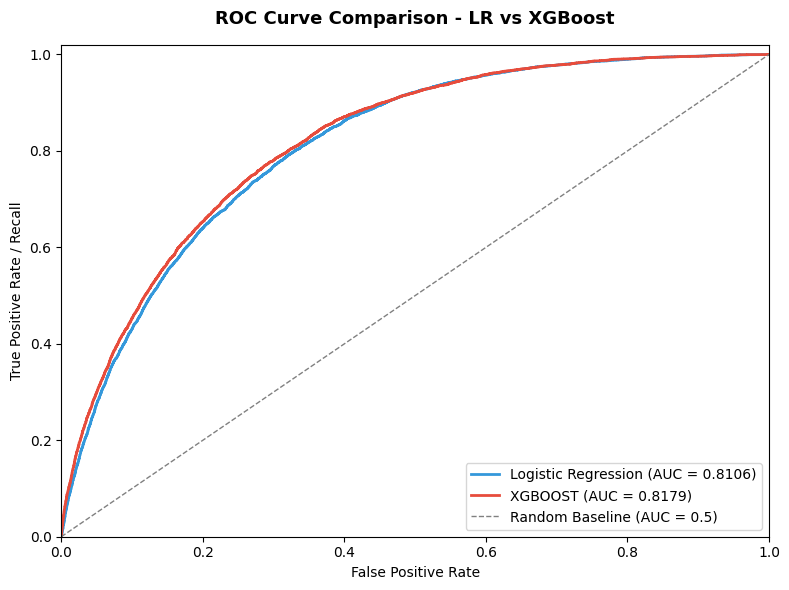

In [15]:
#Plot ROC curves for both models
fig, ax = plt.subplots(figsize=(8, 6))

#Logistic Regression ROC
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_probs)
ax.plot(lr_fpr,
        lr_tpr,
        color='#3498db',
        linewidth=2,
        label=f'Logistic Regression (AUC = {lr_auc:.4f})'
       )

#XGBoost ROC
xgb_fpr, xgb_tpr, _ = roc_curve(y_test, xgb_probs)
ax.plot(xgb_fpr,
        xgb_tpr, 
        color='#e74c3c',
        linewidth=2,
        label=f'XGBOOST (AUC = {xgb_auc:.4f})'
       )

#Random baseline
ax.plot([0, 1], [0, 1], 
        color='grey', 
        linewidth=1,
        linestyle='--',
        label='Random Baseline (AUC = 0.5)')

ax.set_title('ROC Curve Comparison - LR vs XGBoost',
             fontsize=13,
             fontweight='bold',
             pad=15
            )

ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate / Recall")
ax.legend(loc="lower right")
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])

plt.tight_layout()
plt.savefig("../visuals/roc_curve_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
             

## 5. Feature Importance

XGBoost provides feature importance scores that help identify which variables contribute most to the model’s diabetes risk predictions.

Feature importance is calculated based on how often and how effectively each feature is used to split the data across the boosted decision trees. Features with higher importance scores have a stronger influence on the model’s predictions.

This step helps validate the exploratory findings from Notebook 1 by showing whether clinically meaningful variables such as `GenHlth`, `HighBP`, `BMI`, `Age`, and `Income` are also important to the final model.

> Feature importance improves model interpretability by showing which health, lifestyle, and socioeconomic factors drive the prediction most strongly.

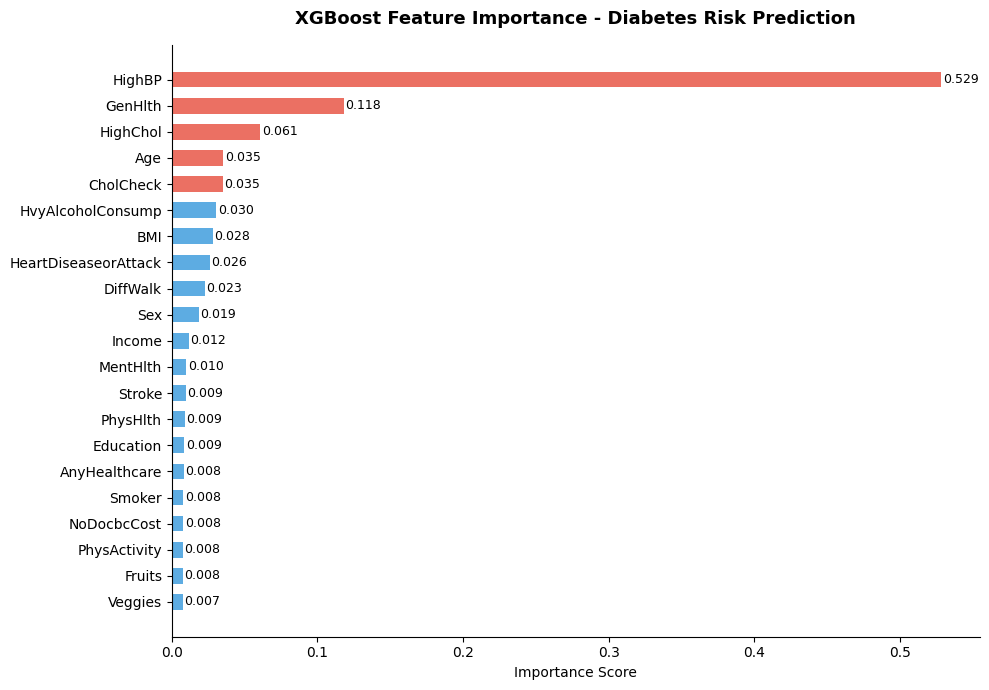

Top 5 most important features:
  Feature  Importance
   HighBP    0.528538
  GenHlth    0.118108
 HighChol    0.060881
      Age    0.035462
CholCheck    0.035138


In [23]:
#Feature importance
fig, ax = plt.subplots(figsize=(10, 7))

importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance':xgb_model.feature_importances_
}).sort_values('Importance', ascending=True)

colors=['#e74c3c' if i >= len(importance_df) - 5
       else '#3498db'
       for i in range(len(importance_df))]
ax.barh(importance_df['Feature'],
        importance_df['Importance'],
        color=colors, alpha=0.8, height=0.6)
ax.set_title('XGBoost Feature Importance - Diabetes Risk Prediction',
            fontsize=13,
             fontweight='bold',
             pad=15)
ax.set_xlabel('Importance Score')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

for i, (val, name) in enumerate(zip(importance_df['Importance'],
                                    importance_df['Feature'])):
    ax.text(val + 0.001,
            i,
            f'{val:.3f}',
            va='center',
            fontsize=9
           )
plt.tight_layout()
plt.savefig('../visuals/feature_importance.png',
           dpi=150,
           bbox_inches='tight')
plt.show()


# Print top 5
print("Top 5 most important features:")
print(importance_df.tail(5)[['Feature', 'Importance']]
      .sort_values('Importance', ascending=False)
      .to_string(index=False))


### Feature Importance Findings

| Rank | Feature | Importance | Category |
|---|---|---:|---|
| 1 | `HighBP` | 0.529 | Clinical |
| 2 | `GenHlth` | 0.118 | Self-reported health |
| 3 | `HighChol` | 0.061 | Clinical |
| 4 | `Age` | 0.035 | Demographic |
| 5 | `CholCheck` | 0.035 | Healthcare access |

**Key Insight:**  
`HighBP` is the most important feature in the XGBoost model, accounting for **52.9%** of the model’s built-in feature importance score. This is more than the combined importance of all other features, making high blood pressure the strongest model driver in this dataset.

This supports the clinical relevance of hypertension as a major diabetes risk indicator.

**Notable Finding:**  
In the exploratory analysis, `GenHlth` had the strongest Pearson correlation with diabetes (**0.277**). However, XGBoost assigns much greater importance to `HighBP` (**0.529**).

This difference shows why model-based feature importance is useful. Pearson correlation only measures simple linear association, while XGBoost can capture non-linear patterns and interactions between features.

**Overall Interpretation:**  
The final model is driven mainly by clinical and health-status indicators, especially high blood pressure, general health, high cholesterol, age, and cholesterol screening history. These results align with the project objective of building an interpretable diabetes risk prediction system based on clinically meaningful features.

## 6. SHAP Analysis — Model Explainability

SHAP, which stands for **SHapley Additive exPlanations**, is used to explain how the XGBoost model makes predictions.

While built-in feature importance shows which variables are important overall, SHAP goes further by showing how each feature contributes to a specific prediction. This helps explain why the model classified a respondent as higher or lower risk for diabetes.

This is especially important in healthcare applications. A risk score alone is not enough; clinicians also need to understand the key factors driving that prediction so they can interpret the result and recommend appropriate follow-up actions.

| SHAP Plot | Purpose |
|---|---|
| **Summary Plot** | Provides a global view of which features have the strongest impact across all respondents |
| **Waterfall Plot** | Explains one individual prediction by showing which features pushed the prediction higher or lower |

> SHAP makes the model more transparent by connecting each prediction back to the clinical, lifestyle, and socioeconomic factors that influenced it.

In [24]:
# SHAP Analysis
explainer = shap.TreeExplainer(xgb_model)

#Use a sample for speed -SHAP on 45k rows is slow
X_test_sample = X_test.sample(1000, random_state=42)
shap_values = explainer.shap_values(X_test_sample)

print("=" * 40)
print(f" SHAP values computed")
print(f" Sample size: {len(X_test_sample):,} rows")
print(f" Shape:{shap_values.shape}")
print("=" * 40)

 SHAP values computed
 Sample size: 1,000 rows
 Shape:(1000, 21)


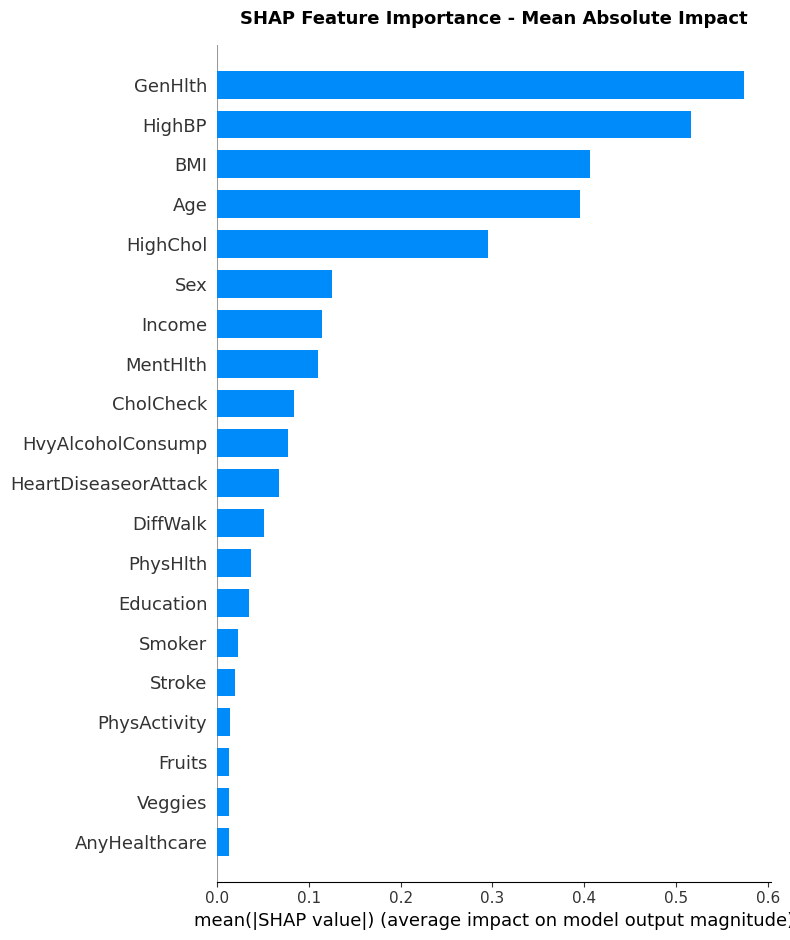

In [25]:
# SHAP Summary Plot
shap.summary_plot(
    shap_values,
    X_test_sample,
    plot_type='bar',
    show=False
)

plt.title('SHAP Feature Importance - Mean Absolute Impact',
        fontsize=13,
         fontweight='bold',
         pad=15)
plt.tight_layout()
plt.savefig('../visuals/shap_summary.png',
           dpi=150,
           bbox_inches='tight')
plt.show()

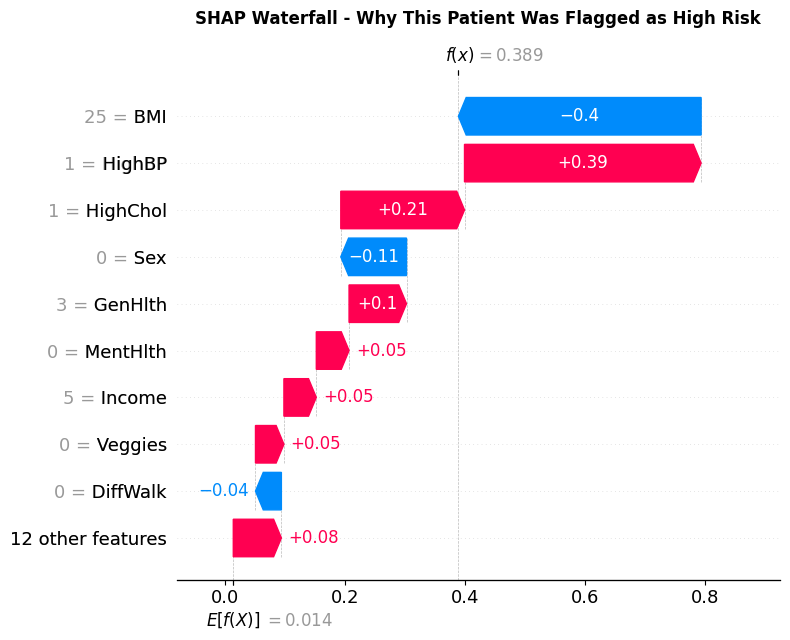

HIGH RISK PATIENT PROFILE
  HighBP                    1
  GenHlth                   3
  BMI                       25
  Age                       13
  HighChol                  1
  PhysActivity              0
  Income                    5
Selected patient predicted diabetes probability: 0.596


In [27]:
# Create predicted probability series aligned with X_test index
xgb_probs_series = pd.Series(xgb_probs, index=X_test.index)

# Get probabilities for the SHAP sample
sample_probs = xgb_probs_series.loc[X_test_sample.index]

# Select a true diabetic patient who was also predicted high risk
high_risk_candidates = X_test_sample[
    (y_test.loc[X_test_sample.index] == 1) &
    (sample_probs >= 0.50)
]

# If none are above 0.50, select the diabetic patient with highest predicted probability
if len(high_risk_candidates) > 0:
    diabetic_idx = high_risk_candidates.index[0]
else:
    diabetic_sample = X_test_sample[y_test.loc[X_test_sample.index] == 1]
    diabetic_idx = sample_probs.loc[diabetic_sample.index].idxmax()

# Get position of selected patient inside the sampled dataframe
sample_pos = X_test_sample.index.get_loc(diabetic_idx)

shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[sample_pos],
        base_values=explainer.expected_value,
        data=X_test_sample.iloc[sample_pos],
        feature_names=X_test_sample.columns.tolist()
    ),
    show=False
)
plt.title('SHAP Waterfall - Why This Patient Was Flagged as High Risk',
         fontsize=12,
         fontweight='bold',
         pad=15
)
plt.tight_layout()
plt.savefig('../visuals/shap_waterfall.png', dpi=150,
           bbox_inches='tight')
plt.show()

# Print the patient profile
print("=" * 45)
print("HIGH RISK PATIENT PROFILE")
print("=" * 45)

patient = X_test_sample.loc[diabetic_idx]
key_features =  ['HighBP', 'GenHlth', 'BMI', 'Age',
                'HighChol', 'PhysActivity', 'Income'
]

for feat in key_features:
    print(f"  {feat:<25} {patient[feat]:.0f}")
print("=" * 45)

# Print selected patient's predicted probability
print(f"Selected patient predicted diabetes probability: {sample_probs.loc[diabetic_idx]:.3f}")

### Individual SHAP Waterfall Interpretation

The SHAP waterfall plot explains why the XGBoost model flagged this patient as high risk for diabetes.

The selected patient has a predicted diabetes probability of **0.596**, meaning the model estimates a **59.6% probability of diabetes risk**. Since this is above the default classification threshold of **0.50**, the patient is classified as high risk.

The plot starts from the model’s baseline output and shows how each feature pushes the prediction higher or lower.

**Main risk-increasing factors:**
- `HighBP = 1` increases the predicted risk, indicating that high blood pressure is a major driver for this patient.
- `HighChol = 1` also pushes the prediction upward, showing that high cholesterol contributes to the high-risk classification.
- `GenHlth = 3` increases risk, suggesting that poorer self-reported general health influenced the model.
- `PhysActivity = 0` contributes to risk because the patient reported no physical activity.

**Main risk-reducing factors:**
- `BMI = 25` reduces the prediction because this BMI value is lower than many higher-risk diabetes profiles.
- `DiffWalk = 0` reduces the prediction because the patient reported no difficulty walking.
- `Sex = 0` also pushes the prediction downward for this individual case.

**Overall Insight:**
This prediction is not based on one factor alone. The model flags the patient as high risk because multiple clinical and lifestyle risk factors, especially high blood pressure and high cholesterol, outweigh the risk-reducing effects of BMI and mobility status.

This type of explanation is useful for a healthcare screening tool because it shows both the predicted risk score and the specific factors driving the model’s decision.

## 7. Export Model Assets

The final XGBoost model and supporting assets are saved for deployment in the Streamlit web application.

The exported files include:

| File | Purpose |
|---|---|
| `model/xgb_model.pkl` | Trained XGBoost model used for diabetes risk prediction |
| `model/explainer.pkl` | SHAP explainer used to explain individual predictions |
| `model/feature_names.pkl` | Ordered feature list required to align user inputs with the model |
| `data/feature_importance.csv` | Feature importance table for interpretation and dashboard display |

Saving these assets allows the Streamlit app to load the trained model, accept patient inputs, generate predictions, and explain the main factors driving each risk score.

In [28]:
import os
# Create folders if they do not exist
os.makedirs("model", exist_ok=True)
os.makedirs("data", exist_ok=True)

# Save XGBoost model
with open("model/xgb_model.pkl", "wb") as f:
    pickle.dump(xgb_model, f)

#Save SHAP explainer
with open("model/explainer.pkl", "wb") as f:
    pickle.dump(explainer, f)

# Save feature names
feature_names = X_train.columns.tolist()
with open("model/feature_names.pkl", "wb") as f:
    pickle.dump(feature_names, f)

# Save feature importance
importance_df.to_csv('data/feature_importance.csv', index=False)

print("=" * 40)
print("  FILES SAVED SUCCESSFULLY")
print("=" * 40)
print("    model/xgb_model.pkl")
print("    model/explainer.pkl")
print("    model/feature_names.pkl")
print("    data/feature_importance.csv")
print("=" * 40)
    

  FILES SAVED SUCCESSFULLY
    model/xgb_model.pkl
    model/explainer.pkl
    model/feature_names.pkl
    data/feature_importance.csv


---
## ✅ Modelling Complete

| Metric | Logistic Regression | XGBoost | Winner |
|---|---:|---:|---|
| ROC-AUC | 0.8106 | 0.8179 | ✅ XGBoost |
| Recall (Diabetes) | 0.76 | 0.78 | ✅ XGBoost |
| Precision (Diabetes) | 0.32 | 0.32 | Draw |
| F1-score (Diabetes) | 0.45 | 0.45 | Draw |

**Final model selected:** XGBoost

XGBoost was selected as the final model because it achieved the highest **ROC-AUC** and the best **Recall for the Diabetes class**, which is the most important metric for this early detection use case.

### Top 5 SHAP Features Driving Predictions

| Rank | Feature | Interpretation |
|---|---|---|
| 1 | `GenHlth` | General health self-rating |
| 2 | `HighBP` | High blood pressure status |
| 3 | `BMI` | Body mass index |
| 4 | `Age` | Age group |
| 5 | `HighChol` | High cholesterol status |

These SHAP results show that the model is mainly driven by clinically meaningful and health-related variables, supporting the reliability and interpretability of the final diabetes risk prediction model.

### Files Exported for Streamlit App

| File | Purpose |
|---|---|
| `model/xgb_model.pkl` | Trained XGBoost model |
| `model/explainer.pkl` | SHAP TreeExplainer |
| `model/feature_names.pkl` | Ordered feature column names |
| `data/feature_importance.csv` | Feature importance scores |

> **Next:** Build the Streamlit web application in `app/app.py`.